In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

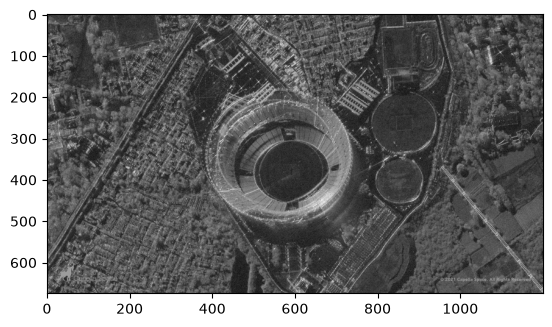

In [3]:
image = cv2.imread('data/sar_1.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) 
plt.imshow(image_gray, cmap="gray")

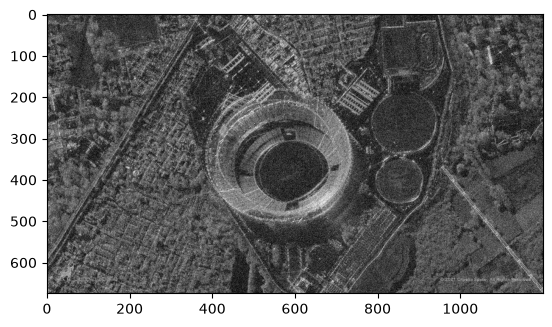

In [5]:
noise = np.random.normal(0, 25, image_gray.shape).astype(np.float32)
noisy_image = image_gray.astype(np.float32) + noise
noisy_image = np.clip(noisy_image, 0, 255).astype(np.uint8)
plt.imshow(noisy_image, cmap="gray")

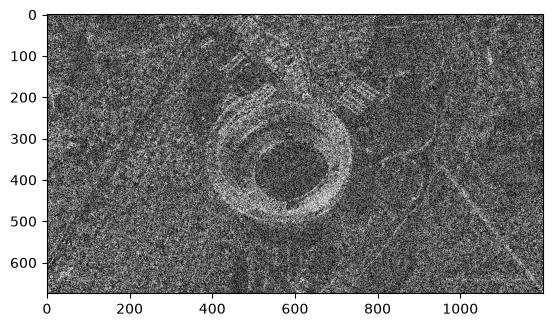

In [15]:
signs = np.random.choice([-1, 1], size=image_gray.shape)
const_noise = (signs * 100).astype(np.float32)
img_const = np.clip(image_gray.astype(np.float32) + const_noise, 0, 255).astype(np.uint8)
plt.imshow(img_const, cmap="gray")

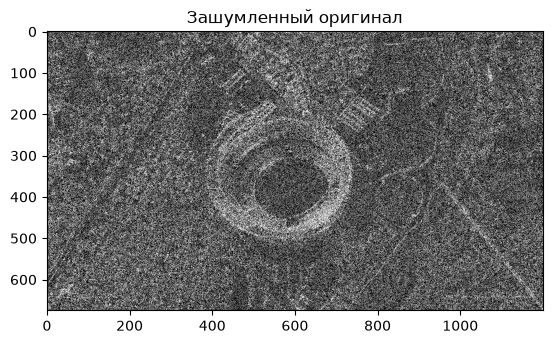

In [40]:
plt.imshow(img_const, cmap="gray")
plt.title("Зашумленный оригинал")
plt.show()

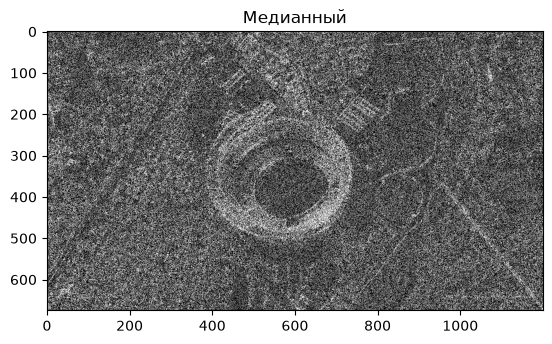

In [35]:
median_3 = cv2.medianBlur(img_const, 1)

plt.imshow(median_3, cmap="gray")
plt.title("Медианный")

plt.show()

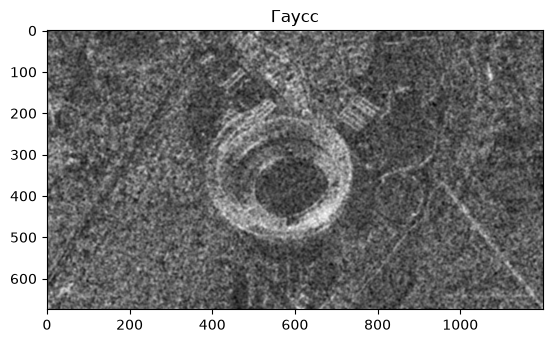

In [36]:
gauss_strong = cv2.GaussianBlur(img_const, (7, 7), sigmaX=2.5)

plt.imshow(gauss_strong, cmap="gray")
plt.title("Гаусс")

plt.show()


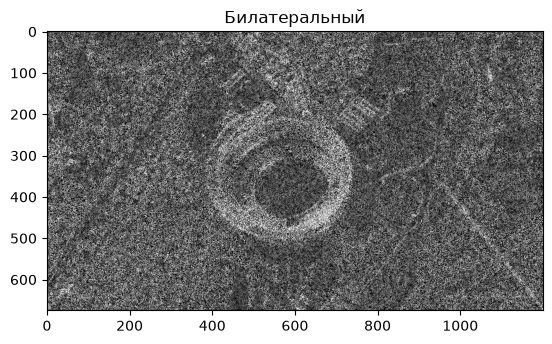

In [37]:
bilat_strong = cv2.bilateralFilter(img_const, d=9, sigmaColor=75, sigmaSpace=75)

plt.imshow(bilat_strong, cmap="gray")
plt.title("Билатеральный")

plt.show()


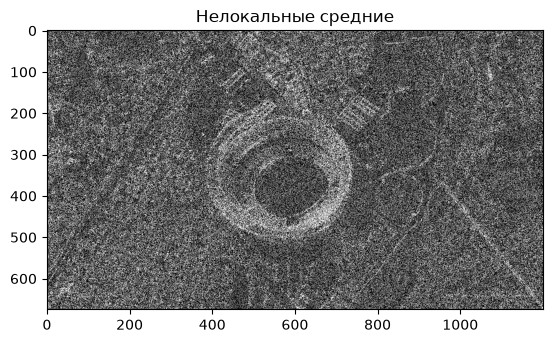

In [39]:
nlm = cv2.fastNlMeansDenoising(
    img_const, None, h=20, templateWindowSize=7, searchWindowSize=21
)

plt.imshow(nlm, cmap="gray")
plt.title("Нелокальные средние")

plt.show()
